# Version 3 : Random Survival Forest avec Features Cytogénétiques

**Objectif** : Intégrer les données cytogénétiques (anomalies chromosomiques) pour maximiser la performance de prédiction de survie.

**Améliorations par rapport aux versions précédentes** :
- **Version 1** : Features cliniques uniquement (C-index val: baseline)
- **Version 2** : + Features moléculaires (mutations génétiques) → C-index val: 0.7334
- **Version 3** : + Features cytogénétiques (anomalies chromosomiques) → Objectif: ~0.74-0.76

**Features cytogénétiques (~30 features)** :
- Types d'anomalies (del, t, inv, +, -)
- Chromosomes affectés (1-22, X, Y)
- Complexité du caryotype
- Marqueurs pronostiques connus (monosomie 7, trisomie 8, del(5q), etc.)

**Total features** : ~118 (28 clinical + 60 molecular + 30 cytogenetic)

## 1. Import des bibliothèques

In [1]:
# Import des bibliothèques standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Survival analysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw
from sksurv.util import Surv

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


## 2. Chargement des données

In [2]:
# Chemins des fichiers
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

# Chargement des données cliniques
clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
clinical_test = pd.read_csv(f"{DATA_PATH}\\X_test\\clinical_test.csv")

# Chargement des données moléculaires
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")
molecular_test = pd.read_csv(f"{DATA_PATH}\\X_test\\molecular_test.csv")

print(f"Clinical train shape: {clinical_train.shape}")
print(f"Molecular train shape: {molecular_train.shape}")
print(f"Target shape: {target_train.shape}")
print(f"Clinical test shape: {clinical_test.shape}")
print(f"Molecular test shape: {molecular_test.shape}")
print("\n✓ Données chargées")

Clinical train shape: (3323, 9)
Molecular train shape: (10935, 11)
Target shape: (3323, 3)
Clinical test shape: (1193, 9)
Molecular test shape: (3089, 11)

✓ Données chargées


## 3. Exploration des données cytogénétiques

In [3]:
print("="*60)
print("CYTOGENETICS DATA (Train)")
print("="*60)

# Afficher des exemples
cyto_samples = clinical_train['CYTOGENETICS'].dropna().head(20)
print("\nExemples de caryotypes:")
for i, cyto in enumerate(cyto_samples, 1):
    print(f"{i:2d}. {cyto}")

print("\n" + "="*60)
print("STATISTIQUES CYTOGÉNÉTIQUES")
print("="*60)
cyto_data = clinical_train['CYTOGENETICS']
print(f"Total patients: {len(clinical_train)}")
print(f"Avec données cytogénétiques: {cyto_data.notna().sum()}")
print(f"Manquantes: {cyto_data.isna().sum()}")
print(f"Taux de remplissage: {cyto_data.notna().sum()/len(clinical_train)*100:.1f}%")

# Analyse des patterns
print("\n" + "="*60)
print("PATTERNS D'ANOMALIES DÉTECTÉS")
print("="*60)
cyto_non_null = cyto_data.dropna()
print(f"Caryotypes normaux (46,xx ou 46,xy): {sum(cyto_non_null.str.match(r'^46,(xx|xy)\[?\d*\]?$', case=False))}")
print(f"Contient 'del' (délétion): {sum(cyto_non_null.str.contains('del', case=False, na=False))}")
print(f"Contient 't(' (translocation): {sum(cyto_non_null.str.contains(r't\(', case=False, na=False))}")
print(f"Contient 'inv' (inversion): {sum(cyto_non_null.str.contains('inv', case=False, na=False))}")
print(f"Contient '+' (gain): {sum(cyto_non_null.str.contains(r'\+', na=False))}")
print(f"Contient '-' (perte): {sum(cyto_non_null.str.contains(r'-[0-9]', na=False))}")
print(f"Marqués 'complex': {sum(cyto_non_null.str.contains('complex', case=False, na=False))}")

CYTOGENETICS DATA (Train)

Exemples de caryotypes:
 1. 46,xy,del(20)(q12)[2]/46,xy[18]
 2. 46,xx
 3. 46,xy,t(3;3)(q25;q27)[8]/46,xy[12]
 4. 46,xy,del(3)(q26q27)[15]/46,xy[5]
 5. 46,xx,t(3;9)(p13;q22)[10]/46,xx[10]
 6. 46,xx[20]
 7. 46,xy[20]
 8. 46,xy[20]
 9. 45,xx,del(5)(q13q33),inc[2]/46,xx[2]
10. 46,xx[20]
11. complex
12. complex
13. 45,xy,-7[2]/46,xy[18]
14. 47,xy,+8[16]/46,xy[2]
15. 47,xx,+8[20]
16. 45,xx,dic(5;17)(q13;p11.2),add(7)(q11.2),der(16)t(1;16)(p22;q24),inc[cp9]/46,xx[11]
17. 46,xy[21]
18. 46,xx[8]
19. 46,xx,t(7;12)(q11.2;p13)[20]
20. 45,xy,-7[19]/46,xy[1]

STATISTIQUES CYTOGÉNÉTIQUES
Total patients: 3323
Avec données cytogénétiques: 2936
Manquantes: 387
Taux de remplissage: 88.4%

PATTERNS D'ANOMALIES DÉTECTÉS
Caryotypes normaux (46,xx ou 46,xy): 1689
Contient 'del' (délétion): 614
Contient 't(' (translocation): 190
Contient 'inv' (inversion): 44
Contient '+' (gain): 485
Contient '-' (perte): 328
Marqués 'complex': 12


## 4. Feature Engineering Cytogénétique

### 4.1 Fonction de création des features cytogénétiques

In [4]:
def create_cytogenetic_features(clinical_df):
    """
    Crée les features cytogénétiques à partir de la colonne CYTOGENETICS.
    
    Parameters:
    -----------
    clinical_df : DataFrame
        Données cliniques avec colonne CYTOGENETICS et ID
    
    Returns:
    --------
    DataFrame avec les features cytogénétiques pour chaque patient
    """
    
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # ===== 1. TYPES D'ANOMALIES =====
    
    # Délétion (del)
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    
    # Translocation (t)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    
    # Inversion (inv)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    
    # Gain chromosomique (+)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    
    # Perte chromosomique (-)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    
    # Autres anomalies (add, ins, etc.)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    
    # ===== 2. COMPLEXITÉ DU CARYOTYPE =====
    
    # Nombre total d'anomalies
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + 
        cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + 
        cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] +
        cyto_features['cyto_other_count']
    )
    
    # Caryotype normal
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    
    # Caryotype complexe (≥3 anomalies ou marqué "complex")
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # ===== 3. CHROMOSOMES AFFECTÉS =====
    
    # Chromosomes 1-22, X, Y
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    
    for chrom in chromosomes:
        # Pattern pour détecter le chromosome (y compris dans del, t, inv, etc.)
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    
    # ===== 4. MARQUEURS PRONOSTIQUES CONNUS =====
    
    # Monosomie 7 (-7) - Mauvais pronostic
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    
    # Trisomie 8 (+8) - Pronostic intermédiaire
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    
    # del(5q) - Syndrome 5q-
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    
    # del(20q)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    
    # Anomalie chromosome 3
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    
    # Anomalie chromosome 7 (autres que monosomie)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    
    # ===== 5. GESTION DES VALEURS MANQUANTES =====
    
    # Pour les patients sans données cytogénétiques, mettre 0
    cyto_features = cyto_features.fillna(0)
    
    print(f"✓ Features cytogénétiques créées: {cyto_features.shape[1]} colonnes")
    print(f"  - Types d'anomalies: 6 features (del, t, inv, gain, loss, other)")
    print(f"  - Binaires des types: 5 features")
    print(f"  - Complexité: 3 features (total, normal, complex)")
    print(f"  - Chromosomes affectés: 24 features (chr1-22, X, Y)")
    print(f"  - Marqueurs pronostiques: 6 features")
    
    return cyto_features

print("✓ Fonction create_cytogenetic_features définie")

✓ Fonction create_cytogenetic_features définie


### 4.2 Fonction de création des features moléculaires (Version 2)

In [5]:
def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """
    Crée les features moléculaires pour un ensemble de patients.
    (Réutilisée de Version 2)
    """
    
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    # 1. Comptage de mutations
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    # 2. Agrégation de VAF
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'),
        ('vaf_max', 'max'),
        ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    # 3. Features par type d'effet
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    effect_counts = effect_counts.reset_index()
    mol_features = mol_features.merge(effect_counts, on='ID', how='left')
    
    # 4. Présence de gènes spécifiques
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
    
    for gene in top_genes_list:
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    # 5. Imputation par 0
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    mol_features = mol_features.set_index('ID')
    
    print(f"✓ Features moléculaires créées: {mol_features.shape[1]} colonnes")
    
    return mol_features

print("✓ Fonction create_molecular_features définie")

✓ Fonction create_molecular_features définie


### 4.3 Création de toutes les features

In [6]:
print("="*60)
print("CRÉATION DES FEATURES - TRAIN")
print("="*60)

# Features cytogénétiques
print("\n1. Features cytogénétiques...")
cyto_features_train = create_cytogenetic_features(clinical_train)

# Features moléculaires
print("\n2. Features moléculaires...")
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)

print("\n" + "="*60)
print("RÉSUMÉ DES FEATURES CRÉÉES")
print("="*60)
print(f"Cytogénétiques: {cyto_features_train.shape[1]} features")
print(f"Moléculaires: {mol_features_train.shape[1]} features")

CRÉATION DES FEATURES - TRAIN

1. Features cytogénétiques...
✓ Features cytogénétiques créées: 44 colonnes
  - Types d'anomalies: 6 features (del, t, inv, gain, loss, other)
  - Binaires des types: 5 features
  - Complexité: 3 features (total, normal, complex)
  - Chromosomes affectés: 24 features (chr1-22, X, Y)
  - Marqueurs pronostiques: 6 features

2. Features moléculaires...
✓ Features moléculaires créées: 60 colonnes

RÉSUMÉ DES FEATURES CRÉÉES
Cytogénétiques: 44 features
Moléculaires: 60 features


## 5. Intégration de toutes les features

In [7]:
# Nettoyer la target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Filtrer clinical_train
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID')
clinical_train_clean = clinical_train_clean.loc[target_clean.index]

print(f"✓ Données nettoyées: {len(clinical_train_clean)} patients")
print(f"  Décès: {target_clean['OS_STATUS'].sum()}")
print(f"  Censurés: {(~target_clean['OS_STATUS']).sum()}")

✓ Données nettoyées: 3173 patients
  Décès: 1600
  Censurés: 1573


In [8]:
# Features cliniques numériques
numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()

# Encodage de CENTER
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)

# Features cliniques
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

print(f"✓ Features cliniques: {X_clinical.shape[1]} colonnes")

✓ Features cliniques: 28 colonnes


In [9]:
# Aligner toutes les features
mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)

# Combiner TOUTES les features
X_combined = pd.concat([
    X_clinical, 
    mol_features_train_aligned, 
    cyto_features_train_aligned
], axis=1)

print("="*60)
print("FEATURES COMBINÉES (CLINICAL + MOLECULAR + CYTOGENETIC)")
print("="*60)
print(f"Total features: {X_combined.shape[1]}")
print(f"  Clinical: {X_clinical.shape[1]}")
print(f"  Molecular: {mol_features_train_aligned.shape[1]}")
print(f"  Cytogenetic: {cyto_features_train_aligned.shape[1]}")
print(f"\nPatients: {X_combined.shape[0]}")

FEATURES COMBINÉES (CLINICAL + MOLECULAR + CYTOGENETIC)
Total features: 132
  Clinical: 28
  Molecular: 60
  Cytogenetic: 44

Patients: 3173


## 6. Imputation et préparation pour l'entraînement

In [10]:
# Imputation des valeurs manquantes par la médiane
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_combined),
    index=X_combined.index,
    columns=X_combined.columns
)

print("✓ Imputation terminée")
print(f"  Valeurs manquantes restantes: {X_imputed.isnull().sum().sum()}")
print(f"  Shape: {X_imputed.shape}")

✓ Imputation terminée
  Valeurs manquantes restantes: 0
  Shape: (3173, 132)


In [11]:
# Création du format survival
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

print(f"✓ Target survival créée: {len(y_surv)} observations")
print(f"  Événements: {y_surv['OS_STATUS'].sum()}")

✓ Target survival créée: 3173 observations
  Événements: 1600


## 7. Split Train/Validation

In [12]:
# Split 70/30
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, 
    y_surv,
    test_size=0.3,
    random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print("="*60)
print("SPLIT TRAIN/VALIDATION")
print("="*60)
print(f"Train set: {X_train.shape[0]} patients ({X_train.shape[0]/len(X_imputed)*100:.1f}%)")
print(f"  - Features: {X_train.shape[1]}")
print(f"  - Décès: {y_train['OS_STATUS'].sum()}")
print(f"  - Censurés: {(~y_train['OS_STATUS']).sum()}")

print(f"\nValidation set: {X_val.shape[0]} patients ({X_val.shape[0]/len(X_imputed)*100:.1f}%)")
print(f"  - Features: {X_val.shape[1]}")
print(f"  - Décès: {y_val['OS_STATUS'].sum()}")
print(f"  - Censurés: {(~y_val['OS_STATUS']).sum()}")

SPLIT TRAIN/VALIDATION
Train set: 2221 patients (70.0%)
  - Features: 132
  - Décès: 1120
  - Censurés: 1101

Validation set: 952 patients (30.0%)
  - Features: 132
  - Décès: 480
  - Censurés: 472


## 8. Entraînement du Random Survival Forest

In [13]:
# Configuration du modèle RSF (même architecture que V1 et V2)
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("="*60)
print("CONFIGURATION DU MODÈLE")
print("="*60)
print(f"Nombre d'arbres: {rsf.n_estimators}")
print(f"Min samples split: {rsf.min_samples_split}")
print(f"Min samples leaf: {rsf.min_samples_leaf}")
print(f"Max features: {rsf.max_features}")
print(f"\n🌲 Entraînement en cours...")

CONFIGURATION DU MODÈLE
Nombre d'arbres: 100
Min samples split: 10
Min samples leaf: 15
Max features: sqrt

🌲 Entraînement en cours...


In [14]:
# Entraînement
rsf.fit(X_train, y_train)
print("\n✓ Modèle entraîné avec succès!")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.4s



✓ Modèle entraîné avec succès!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.1s finished


## 9. Évaluation du modèle

In [15]:
# Prédiction
y_pred_train = rsf.predict(X_train)
y_pred_val = rsf.predict(X_val)

# Calcul du C-index
c_index_train = concordance_index_censored(
    y_train['OS_STATUS'], 
    y_train['OS_YEARS'], 
    y_pred_train
)[0]

c_index_val = concordance_index_censored(
    y_val['OS_STATUS'], 
    y_val['OS_YEARS'], 
    y_pred_val
)[0]

print("="*60)
print("PERFORMANCE DU MODÈLE (C-INDEX)")
print("="*60)
print(f"Train C-index: {c_index_train:.4f}")
print(f"Validation C-index: {c_index_val:.4f}")
print(f"\nDifférence (overfitting): {c_index_train - c_index_val:.4f}")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s


PERFORMANCE DU MODÈLE (C-INDEX)
Train C-index: 0.7813
Validation C-index: 0.7320

Différence (overfitting): 0.0493


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.7s finished


## 10. Importance des features

In [16]:
# Calcul de l'importance
print("Calcul de l'importance des features (peut prendre quelques minutes)...")

perm_importance = permutation_importance(
    rsf, X_val, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\n✓ Importance calculée")
print("\n" + "="*60)
print("TOP 30 FEATURES LES PLUS IMPORTANTES")
print("="*60)
display(feature_importance_df.head(30))

Calcul de l'importance des features (peut prendre quelques minutes)...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.6s finished



✓ Importance calculée

TOP 30 FEATURES LES PLUS IMPORTANTES


,feature,importance,std
0,BM_BLAST,0.014065,0.004249
4,HB,0.010969,0.001636
5,PLT,0.007722,0.002334
31,vaf_sum,0.007029,0.001754
28,mutation_count_total,0.004192,0.001613
42,effect_non_synonymous_codon,0.003220,0.001364
101,cyto_complex,0.002446,0.002170
1,WBC,0.002261,0.000585
72,gene_RUNX1_present,0.002210,0.001659
2,ANC,0.001889,0.000802


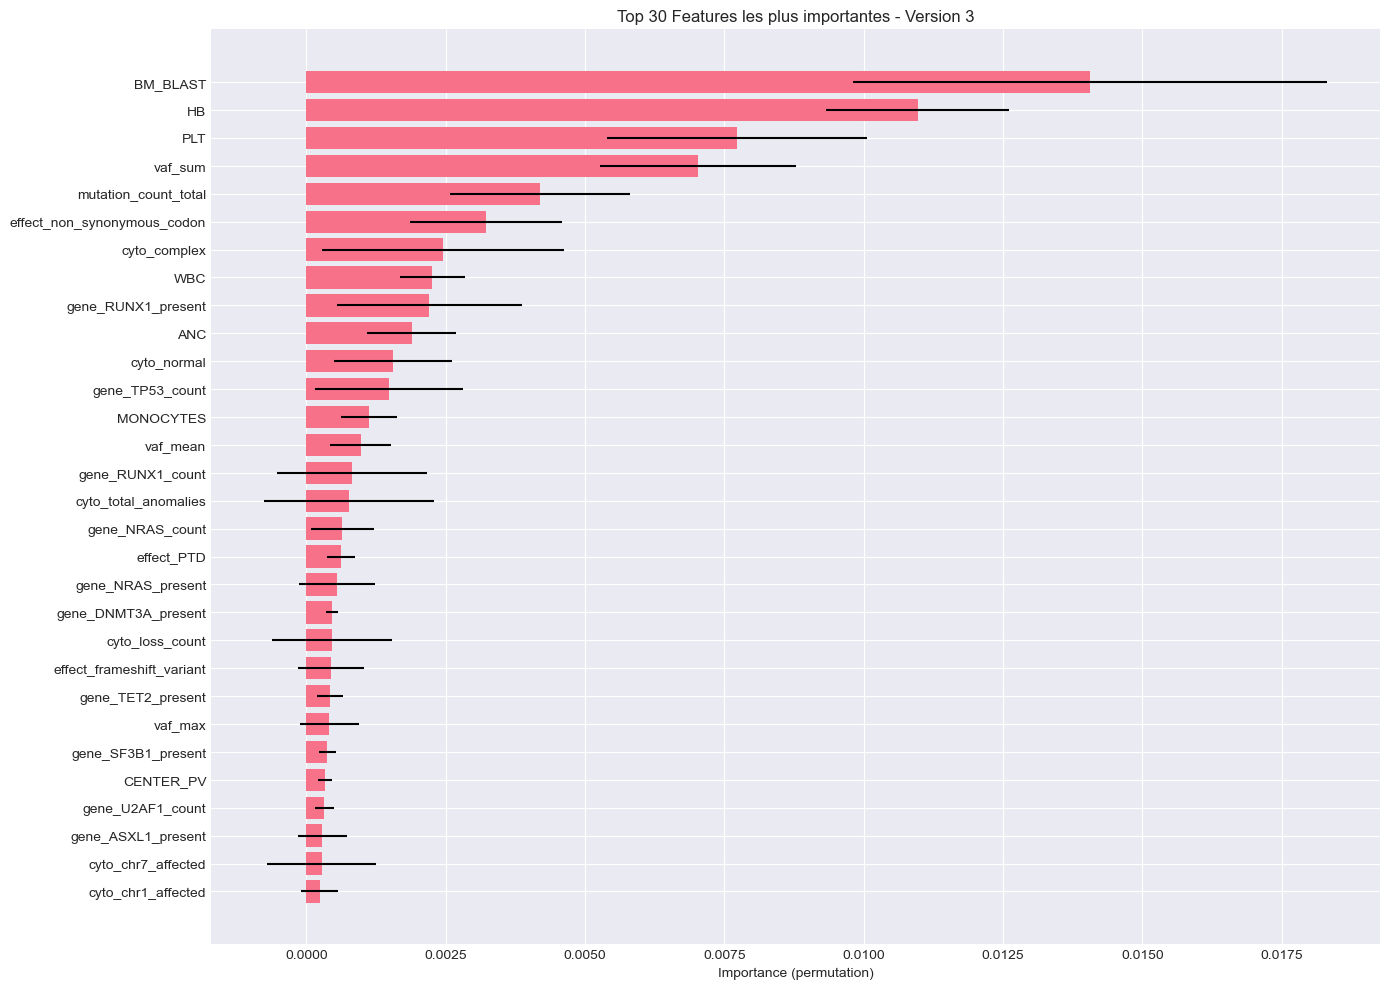

In [17]:
# Visualisation
plt.figure(figsize=(14, 10))
top_n = 30
top_features = feature_importance_df.head(top_n)

plt.barh(range(top_n), top_features['importance'], xerr=top_features['std'])
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Importance (permutation)')
plt.title(f'Top {top_n} Features les plus importantes - Version 3')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Analyse comparative par type de features

In [18]:
# Catégoriser les features
clinical_feature_names = X_clinical.columns.tolist()
molecular_feature_names = mol_features_train_aligned.columns.tolist()
cytogenetic_feature_names = cyto_features_train_aligned.columns.tolist()

# Importance par type
clinical_importance = feature_importance_df[
    feature_importance_df['feature'].isin(clinical_feature_names)
]['importance']

molecular_importance = feature_importance_df[
    feature_importance_df['feature'].isin(molecular_feature_names)
]['importance']

cytogenetic_importance = feature_importance_df[
    feature_importance_df['feature'].isin(cytogenetic_feature_names)
]['importance']

print("="*60)
print("COMPARAISON IMPORTANCE PAR TYPE DE FEATURE")
print("="*60)
print(f"\nImportance moyenne Clinical: {clinical_importance.mean():.6f}")
print(f"Importance moyenne Molecular: {molecular_importance.mean():.6f}")
print(f"Importance moyenne Cytogenetic: {cytogenetic_importance.mean():.6f}")

print(f"\nTop 20 features - Breakdown:")
top_20 = feature_importance_df.head(20)
print(f"  Clinical: {sum(top_20['feature'].isin(clinical_feature_names))}")
print(f"  Molecular: {sum(top_20['feature'].isin(molecular_feature_names))}")
print(f"  Cytogenetic: {sum(top_20['feature'].isin(cytogenetic_feature_names))}")

COMPARAISON IMPORTANCE PAR TYPE DE FEATURE

Importance moyenne Clinical: 0.001391
Importance moyenne Molecular: 0.000434
Importance moyenne Cytogenetic: 0.000069

Top 20 features - Breakdown:
  Clinical: 6
  Molecular: 11
  Cytogenetic: 3


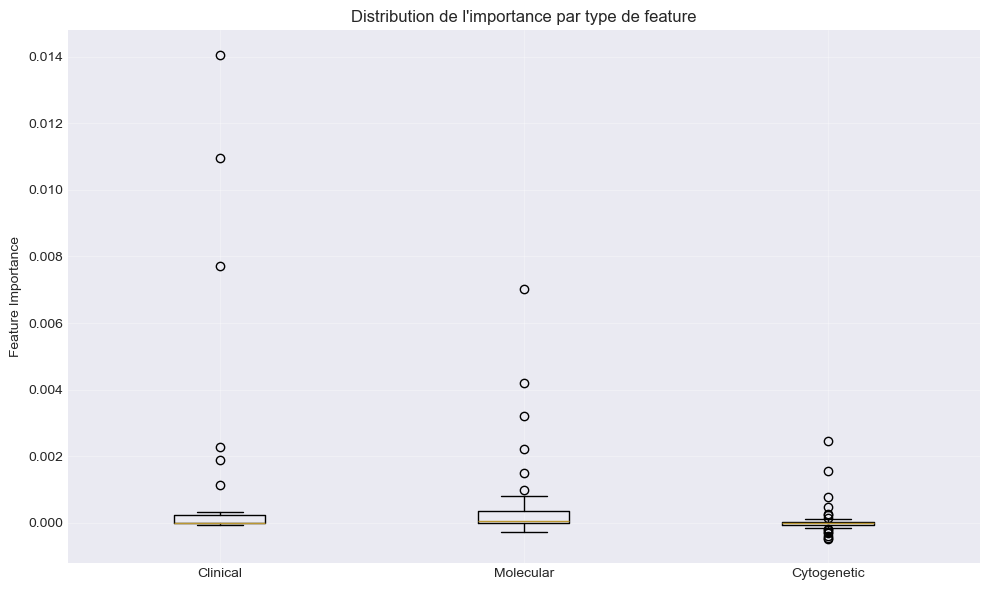


✓ Visualisation créée


In [19]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [
    clinical_importance.values,
    molecular_importance.values,
    cytogenetic_importance.values
]

ax.boxplot(data_to_plot, labels=['Clinical', 'Molecular', 'Cytogenetic'])
ax.set_ylabel('Feature Importance')
ax.set_title('Distribution de l\'importance par type de feature')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Visualisation créée")

## 12. Top features cytogénétiques

TOP 15 FEATURES CYTOGÉNÉTIQUES


,feature,importance,std
101,cyto_complex,0.002446,0.002170
100,cyto_normal,0.001556,0.001054
99,cyto_total_anomalies,0.000765,0.001518
96,cyto_loss_count,0.000460,0.001076
108,cyto_chr7_affected,0.000277,0.000977
102,cyto_chr1_affected,0.000242,0.000331
119,cyto_chr18_affected,0.000149,0.000303
98,cyto_other_count,0.000106,0.000179
131,cyto_chr7_abnormal,0.000069,0.000072
128,cyto_del5q,0.000057,0.000107


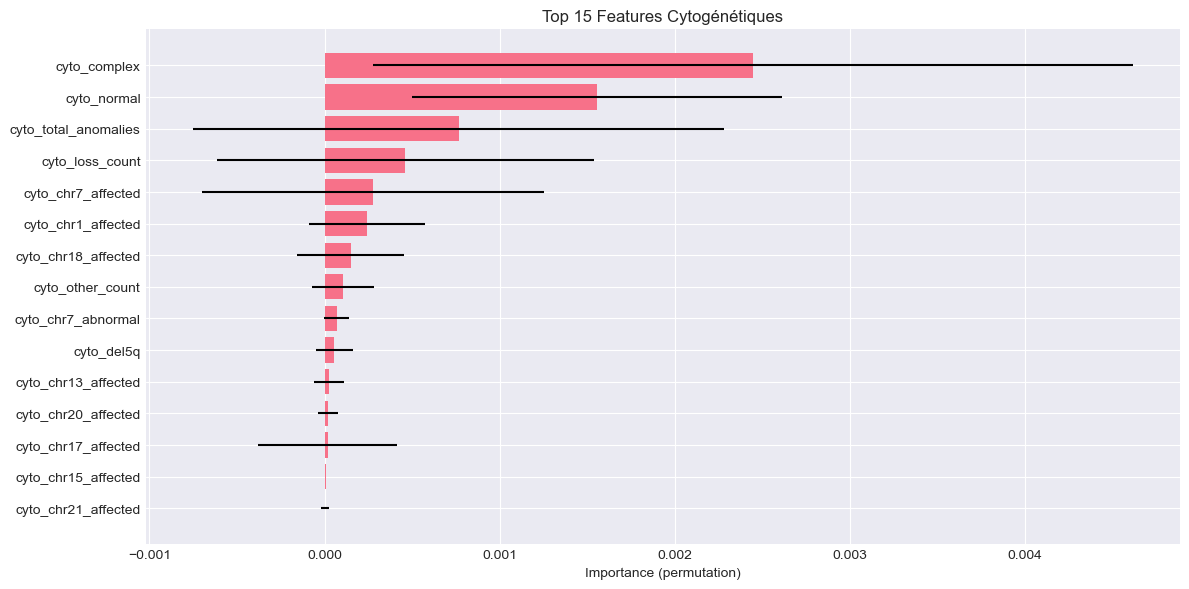

In [20]:
# Analyser les features cytogénétiques les plus importantes
cyto_importance_df = feature_importance_df[
    feature_importance_df['feature'].isin(cytogenetic_feature_names)
].head(15)

print("="*60)
print("TOP 15 FEATURES CYTOGÉNÉTIQUES")
print("="*60)
display(cyto_importance_df)

# Visualisation
plt.figure(figsize=(12, 6))
plt.barh(range(len(cyto_importance_df)), cyto_importance_df['importance'], 
         xerr=cyto_importance_df['std'])
plt.yticks(range(len(cyto_importance_df)), cyto_importance_df['feature'])
plt.xlabel('Importance (permutation)')
plt.title('Top 15 Features Cytogénétiques')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Préparation du test set

In [ ]:
print("="*60)
print("CRÉATION DES FEATURES - TEST")
print("="*60)

# Features cytogénétiques
print("\n1. Features cytogénétiques...")
cyto_features_test = create_cytogenetic_features(clinical_test)

# Features moléculaires
print("\n2. Features moléculaires...")
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

print("\n✓ Features test créées")

In [ ]:
# Préparer les features cliniques
clinical_test_indexed = clinical_test.set_index('ID')
X_numeric_test = clinical_test_indexed[numeric_features].copy()

# Encodage CENTER
center_encoded_test = pd.get_dummies(clinical_test_indexed['CENTER'], prefix='CENTER', drop_first=True)
for col in center_encoded.columns:
    if col not in center_encoded_test.columns:
        center_encoded_test[col] = 0
center_encoded_test = center_encoded_test[center_encoded.columns]

X_clinical_test = pd.concat([X_numeric_test, center_encoded_test], axis=1)

# Aligner toutes les features
mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)

# Combiner
X_test_combined = pd.concat([
    X_clinical_test, 
    mol_features_test_aligned, 
    cyto_features_test_aligned
], axis=1)

# Aligner colonnes avec train
for col in X_combined.columns:
    if col not in X_test_combined.columns:
        X_test_combined[col] = 0
X_test_combined = X_test_combined[X_combined.columns]

print(f"✓ Features test préparées: {X_test_combined.shape}")

In [ ]:
# Imputation
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_combined),
    index=X_test_combined.index,
    columns=X_test_combined.columns
)

print(f"✓ Test set imputé")
print(f"  Shape: {X_test_imputed.shape}")

## 14. Prédictions finales

In [ ]:
# Ré-entraîner sur toutes les données
print("Ré-entraînement du modèle sur l'ensemble complet...")
rsf_final = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rsf_final.fit(X_imputed, y_surv)
print("\n✓ Modèle final entraîné")

In [ ]:
# Prédictions
predictions_test = rsf_final.predict(X_test_imputed)

submission = pd.DataFrame({
    'ID': X_test_imputed.index,
    'PRED': predictions_test
})

submission_path = f"{DATA_PATH}\\submission_rsf_cytogenetics.csv"
submission.to_csv(submission_path, index=False)

print("="*60)
print("SOUMISSION GÉNÉRÉE")
print("="*60)
print(f"Fichier: {submission_path}")
print(f"Nombre de prédictions: {len(submission)}")
print(f"\nPremières prédictions:")
display(submission.head(10))

print(f"\nStatistiques:")
print(submission['PRED'].describe())

## 15. Comparaison des 3 versions

In [ ]:
print("="*60)
print("COMPARAISON DES 3 VERSIONS")
print("="*60)

# Créer un DataFrame comparatif
comparison_df = pd.DataFrame({
    'Version': ['V1: Clinical only', 'V2: + Molecular', 'V3: + Cytogenetic'],
    'Features': [
        28,  # Clinical
        88,  # Clinical + Molecular
        X_combined.shape[1]  # Clinical + Molecular + Cytogenetic
    ],
    'Val C-index': [
        'À compléter',  # À remplir avec résultat V1
        0.7334,  # Résultat V2 fourni par l'utilisateur
        c_index_val  # Résultat V3 actuel
    ]
})

display(comparison_df)

print("\n✓ Version 3 complète avec:")
print(f"  • {X_clinical.shape[1]} features cliniques")
print(f"  • {mol_features_train_aligned.shape[1]} features moléculaires")
print(f"  • {cyto_features_train_aligned.shape[1]} features cytogénétiques")
print(f"  • TOTAL: {X_combined.shape[1]} features")

## 16. Résumé final

In [ ]:
print("="*60)
print("RÉSUMÉ - VERSION 3: RSF COMPLET")
print("="*60)

print("\n📊 FEATURES:")
print(f"  Clinical: {X_clinical.shape[1]}")
print(f"  Molecular: {mol_features_train_aligned.shape[1]}")
print(f"  Cytogenetic: {cyto_features_train_aligned.shape[1]}")
print(f"  TOTAL: {X_combined.shape[1]}")

print("\n🧬 CYTOGENETIC BREAKDOWN:")
print("  • Anomaly types & counts: 11 features")
print("  • Complexity metrics: 3 features")
print("  • Chromosome involvement: 24 features")
print("  • Prognostic markers: 6 features")

print("\n📈 PERFORMANCE:")
print(f"  Train C-index: {c_index_train:.4f}")
print(f"  Validation C-index: {c_index_val:.4f}")
print(f"  Overfitting: {c_index_train - c_index_val:.4f}")

print("\n🏆 TOP 5 FEATURES GLOBALES:")
for idx, row in feature_importance_df.head(5).iterrows():
    if row['feature'] in clinical_feature_names:
        ftype = "Clinical"
    elif row['feature'] in molecular_feature_names:
        ftype = "Molecular"
    else:
        ftype = "Cytogenetic"
    print(f"  {idx+1}. {row['feature']:<35} ({ftype}): {row['importance']:.6f}")

print("\n✓ Version 3 terminée!")
print(f"✓ Soumission: submission_rsf_cytogenetics.csv")